# Annotation Confidence Model

## Logic

The pipeline assigns a compound name to each spectrum (e.g. 'this is arginine'). This notebook asks: **how confident should we be in that claim?**

This is different from the Bayesian MVP, which ranks candidates against each other. Here we evaluate **one specific claim** — the annotation — using evidence that directly supports or contradicts it.

**Approach:** logistic regression predicting P(annotation is wrong) from 7 features, each measuring how well the evidence supports the annotation compound specifically.

**Training data:** 1,186 TP spectra (annotation confirmed correct) + 215 FP spectra (annotation confirmed wrong).

**Evaluation:** 5-fold stratified CV on the training set — the only honest evaluation since all 215 FPs are in training. The 112-spectrum holdout contains only TPs, so it can only check false alarm rate, not AUC.

**Default flag threshold:** confidence < 0.3 → flag for review (52% FP catch, 7% TP false alarm).

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SPECTRA_PATH   = '../data/masswiki_Orbitrap HILIC negESI_2026-03-19.xlsx'
HITS_PATH      = '../data/library_hits/orbitrap_hilic_neg_masswiki_hits.csv'
SOLID_TP_PATH  = '../data/solid_tp.csv'
FLAG_THRESHOLD = 0.3   # conf < FLAG_THRESHOLD → flag for review
print('✓ Imports loaded')

✓ Imports loaded


In [4]:
# Load spectra and assign labels from Oliver's spreadsheet
# Rows 0-1297: re-annotated TP. yy_ prefix: FP. zz_ prefix: TN (excluded).
spectra_raw = pd.read_excel(SPECTRA_PATH, header=4)
spectra_raw['label'] = 'unlabeled'
spectra_raw.loc[:1297, 'label'] = 'TP'
spectra_raw.loc[spectra_raw['name'].str.startswith('yy_', na=False), 'label'] = 'FP'
spectra_raw.loc[spectra_raw['name'].str.startswith('zz_', na=False), 'label'] = 'TN'

solid_tp = pd.read_csv(SOLID_TP_PATH)
holdout_wids = set(solid_tp['wiki_id'])
spectra_raw['holdout'] = spectra_raw['wiki_id'].isin(holdout_wids)

spectra = spectra_raw[spectra_raw['label'].isin(['TP', 'FP'])].copy()
print(f'Annotated spectra: {len(spectra):,}')
print(f'  TP: {(spectra["label"]=="TP").sum()} '
      f'(train: {((spectra["label"]=="TP") & ~spectra["holdout"]).sum()}, '
      f'holdout: {spectra["holdout"].sum()})')
print(f'  FP: {(spectra["label"]=="FP").sum()} (all in training — no held-out FPs)')

hits_raw = pd.read_csv(HITS_PATH)
print(f'Library hits: {len(hits_raw):,}')

Annotated spectra: 1,513
  TP: 1298 (train: 1186, holdout: 112)
  FP: 215 (all in training — no held-out FPs)
Library hits: 267,645


In [5]:
## Feature 1-4: Spectrum-level (from Oliver's spreadsheet)
# These describe properties of the spectrum itself, before looking at any candidate.

# Feature 1: |anno_delta_rt| — deviation between observed RT and expected RT
# for the annotation compound. Large → annotation is inconsistent with chromatography.
# This is the dominant signal (univariate AUC 0.813, matches Oliver's r=0.916).
spectra['anno_delta_rt_abs'] = pd.to_numeric(spectra['anno_delta_rt'], errors='coerce').abs()

# Feature 2: identity_score — best precursor-constrained match in annotation library.
# Low → even the in-house library doesn't support this precursor m/z well.
spectra['identity_score_num'] = pd.to_numeric(spectra['identity_score'], errors='coerce')

# Feature 3: isf_gap = fuzzy - identity (clipped to ≥0).
# fuzzy = open search (no precursor constraint).
# When fuzzy >> identity: MS2 peaks match something well, but not at this precursor m/z.
# Suggests in-source fragmentation — spectrum belongs to a fragment, not the annotation compound.
fuzzy = pd.to_numeric(spectra['fuzzy_score'], errors='coerce')
spectra['isf_gap'] = (fuzzy - spectra['identity_score_num']).clip(lower=0.0)

# Feature 4: spectral entropy — number and evenness of peaks.
# Low entropy → few peaks → any library match is less reliable.
spectra['entropy_num'] = pd.to_numeric(spectra['entropy'], errors='coerce')

spectra['anno_name'] = spectra['name'].str.strip().str.lower()

print('RT coverage:')
for lab in ['TP', 'FP']:
    sub = spectra[spectra['label']==lab]['anno_delta_rt_abs']
    print(f'  {lab}: non-null={sub.notna().sum()}/{len(sub)}, '
          f'median={sub.median():.1f}s, >30s={(sub>30).sum()} ({(sub>30).mean():.1%})')

RT coverage:
  TP: non-null=1295/1298, median=6.4s, >30s=90 (6.9%)
  FP: non-null=211/215, median=30.9s, >30s=107 (49.8%)


In [6]:
## Features 5-7: Annotation-hit-level (from library hits)
# For each spectrum, find the library hit that corresponds to the annotation compound,
# then measure how well the spectral evidence supports it.

spec_join = spectra[['wiki_id', 'anno_name', 'precursor_mz']].copy()
joint = hits_raw.merge(spec_join, on='wiki_id', how='inner')
joint = joint[joint['entropy_similarity'] >= 0.75].copy()

joint['lib_precursor_mz'] = pd.to_numeric(joint['lib_precursor_mz'], errors='coerce')
joint['delta_ppm'] = (
    (joint['precursor_mz'] - joint['lib_precursor_mz'])
    / joint['lib_precursor_mz'] * 1e6
)
joint['lib_name_lower'] = joint['lib_name'].str.strip().str.lower()
joint['is_anno_hit']    = joint['lib_name_lower'] == joint['anno_name']

rows = []
for wid, g in joint.groupby('wiki_id'):
    anno   = g[g['is_anno_hit']]
    others = g[~g['is_anno_hit']]
    if len(anno) > 0:
        best     = anno.loc[anno['entropy_similarity'].idxmax()]
        next_sim = others['entropy_similarity'].max() if len(others) > 0 else 0.0
        rows.append({
            'wiki_id': wid,
            # Feature 5: MS2 match quality for the annotation compound specifically
            'entropy_similarity_anno': best['entropy_similarity'],
            # Feature 6: mass accuracy of the annotation hit
            'delta_ppm_anno_abs': abs(best['delta_ppm']),
            # Feature 7: how much the annotation hit beats the next-best candidate
            # Small gap → another compound matches equally well → annotation uncertain
            'sim_gap_anno': max(0.0, best['entropy_similarity'] - next_sim)
        })
    else:
        # Annotation compound not found in library hits above 0.75 threshold
        rows.append({'wiki_id': wid, 'entropy_similarity_anno': 0.0,
                     'delta_ppm_anno_abs': np.nan, 'sim_gap_anno': 0.0})

spectra = spectra.merge(pd.DataFrame(rows), on='wiki_id', how='left')
has_hit = spectra['entropy_similarity_anno'].gt(0).sum()
print(f'Annotation hit found (sim ≥ 0.75): {has_hit:,}/{len(spectra):,}')

Annotation hit found (sim ≥ 0.75): 1,439/1,513


In [7]:
FEATURE_COLS = [
    'anno_delta_rt_abs',        # RT deviation (dominant signal)
    'identity_score_num',       # Precursor-constrained match quality
    'isf_gap',                  # ISF contamination signal
    'entropy_similarity_anno',  # MS2 match quality for annotation hit
    'delta_ppm_anno_abs',       # Mass accuracy of annotation hit
    'sim_gap_anno',             # Margin over next-best candidate
    'entropy_num',              # Spectral complexity
]

df_model = spectra[['wiki_id', 'label', 'holdout'] + FEATURE_COLS].copy()
df_model['delta_ppm_anno_abs'].fillna(df_model['delta_ppm_anno_abs'].median(), inplace=True)
df_model['anno_delta_rt_abs'].fillna(df_model['anno_delta_rt_abs'].median(), inplace=True)
df_model.fillna(0.0, inplace=True)

df_train   = df_model[~df_model['holdout']].copy()   # 1,186 TP + 215 FP
df_holdout = df_model[df_model['holdout']].copy()    # 112 solid TP only

print('Training set feature distributions:')
print(df_train.groupby('label')[FEATURE_COLS].median().round(3).T.to_string())

Training set feature distributions:
label                        FP     TP
anno_delta_rt_abs        29.884  6.294
identity_score_num        0.768  0.860
isf_gap                   0.040  0.000
entropy_similarity_anno   1.000  1.000
delta_ppm_anno_abs        0.000  0.000
sim_gap_anno              0.158  0.159
entropy_num               1.467  1.677


In [8]:
## Univariate AUC: how well does each feature alone discriminate TP vs FP?

y = (df_train['label'] == 'FP').astype(int)

# Sign convention: features where HIGHER = more likely FP
sign = {
    'anno_delta_rt_abs':       +1,  # large RT gap → suspicious
    'identity_score_num':      -1,  # low identity → suspicious
    'isf_gap':                 +1,  # large ISF gap → suspicious
    'entropy_similarity_anno': -1,  # low MS2 match → suspicious
    'delta_ppm_anno_abs':      +1,  # large ppm → suspicious
    'sim_gap_anno':            -1,  # small margin → suspicious
    'entropy_num':             -1,  # low entropy → suspicious
}

print(f'Feature                        | AUC   | Direction')
print('-' * 55)
for col in FEATURE_COLS:
    a = roc_auc_score(y, df_train[col].values * sign[col])
    direction = 'high → FP' if sign[col] == 1 else 'low → FP'
    print(f'{col:<30} | {a:.3f} | {direction}')

print(f'\nOliver score (all features): 0.840')
print(f'Bayesian MVP posterior:      0.463  (different question)')

Feature                        | AUC   | Direction
-------------------------------------------------------
anno_delta_rt_abs              | 0.803 | high → FP
identity_score_num             | 0.628 | low → FP
isf_gap                        | 0.638 | high → FP
entropy_similarity_anno        | 0.448 | low → FP
delta_ppm_anno_abs             | 0.550 | high → FP
sim_gap_anno                   | 0.513 | low → FP
entropy_num                    | 0.587 | low → FP

Oliver score (all features): 0.840
Bayesian MVP posterior:      0.463  (different question)


In [9]:
## Fit logistic regression with 5-fold stratified CV
# The CV AUC is the only honest TP/FP discrimination estimate
# since all 215 FPs are in the training set.

X = df_train[FEATURE_COLS].values
y = (df_train['label'] == 'FP').astype(int).values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr  = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_aucs  = cross_val_score(lr, X_scaled, y, cv=skf, scoring='roc_auc')
cv_probs = cross_val_predict(lr, X_scaled, y, cv=skf, method='predict_proba')[:, 1]
cv_conf  = 1.0 - cv_probs   # P(annotation is correct)

print(f'5-fold CV AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')
print(f'Folds: {[f"{a:.3f}" for a in cv_aucs]}')

# Fit on all training data for deployment
lr.fit(X_scaled, y)

print(f'\nFeature coefficients (larger |value| = more influential):')
for col, coef in sorted(zip(FEATURE_COLS, lr.coef_[0]), key=lambda x: -abs(x[1])):
    direction = 'FP ↑' if coef > 0 else 'TP ↑'
    print(f'  {col:<32} {coef:+.4f}  ({direction})')

5-fold CV AUC: 0.837 ± 0.021
Folds: ['0.850', '0.851', '0.858', '0.800', '0.827']

Feature coefficients (larger |value| = more influential):
  delta_ppm_anno_abs               -2.2334  (TP ↑)
  anno_delta_rt_abs                +1.2553  (FP ↑)
  identity_score_num               -0.7034  (TP ↑)
  sim_gap_anno                     -0.4620  (TP ↑)
  entropy_num                      -0.1307  (TP ↑)
  isf_gap                          -0.0105  (TP ↑)
  entropy_similarity_anno          +0.0036  (FP ↑)


Threshold | FP caught         | TP flagged (false alarm)
-------------------------------------------------------
  <0.2     |  86/215 (40%)    |  49/1186 (4%)
  <0.3     | 111/215 (52%)    |  85/1186 (7%) ← default
  <0.4     | 127/215 (59%)    | 135/1186 (11%)
  <0.5     | 149/215 (69%)    | 216/1186 (18%)
  <0.6     | 168/215 (78%)    | 323/1186 (27%)
  <0.7     | 189/215 (88%)    | 522/1186 (44%)


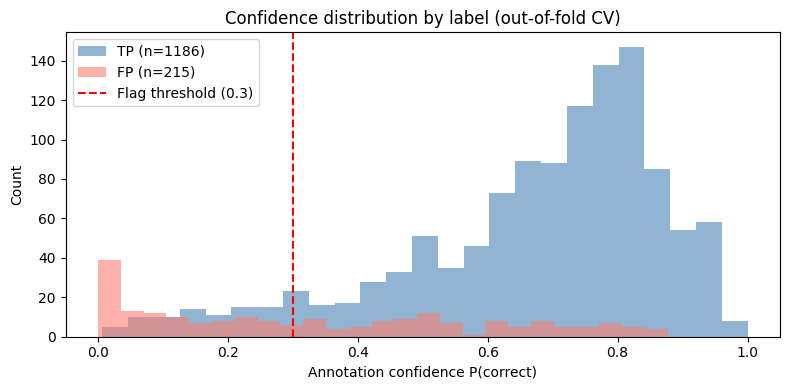

In [10]:
## Threshold analysis: choosing when to flag an annotation
# Confidence = P(annotation is correct). Below threshold → flag for review.
# Uses out-of-fold CV predictions (proper out-of-sample).

y_lab  = (df_train['label'] == 'FP').astype(int).values
tp_conf = cv_conf[y_lab == 0]
fp_conf = cv_conf[y_lab == 1]

print(f'Threshold | FP caught         | TP flagged (false alarm)')
print('-' * 55)
for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    fp_caught  = (fp_conf < thresh).sum()
    tp_flagged = (tp_conf < thresh).sum()
    marker = ' ← default' if thresh == FLAG_THRESHOLD else ''
    print(f'  <{thresh:.1f}     | {fp_caught:3d}/{len(fp_conf)} ({fp_caught/len(fp_conf):.0%})    '
          f'| {tp_flagged:3d}/{len(tp_conf)} ({tp_flagged/len(tp_conf):.0%}){marker}')

# Confidence distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tp_conf, bins=25, alpha=0.6, label=f'TP (n={len(tp_conf)})', color='steelblue')
ax.hist(fp_conf, bins=25, alpha=0.6, label=f'FP (n={len(fp_conf)})', color='salmon')
ax.axvline(FLAG_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Flag threshold ({FLAG_THRESHOLD})')
ax.set_xlabel('Annotation confidence P(correct)')
ax.set_ylabel('Count')
ax.set_title('Confidence distribution by label (out-of-fold CV)')
ax.legend()
plt.tight_layout()
os.makedirs('results/annotation_confidence', exist_ok=True)
plt.savefig('results/annotation_confidence/confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
## Holdout validation: 112 solid TPs
# Cannot compute AUC — holdout has no FPs.
# Checks: do high-confidence correct annotations get high scores?

X_h = scaler.transform(df_holdout[FEATURE_COLS].values)
holdout_prob_fp = lr.predict_proba(X_h)[:, 1]
holdout_conf    = 1.0 - holdout_prob_fp

df_holdout = df_holdout.copy()
df_holdout['annotation_confidence'] = holdout_conf

print('Holdout (112 solid TPs):')
print(f'  Mean confidence: {holdout_conf.mean():.3f}')
print(f'  Median:          {np.median(holdout_conf):.3f}')
print(f'  ≥0.8:            {(holdout_conf >= 0.8).sum()} ({(holdout_conf >= 0.8).mean():.1%})')
print(f'  Flagged (<{FLAG_THRESHOLD}):  {(holdout_conf < FLAG_THRESHOLD).sum()} '
      f'({(holdout_conf < FLAG_THRESHOLD).mean():.1%}) — false alarms')

false_alarms = df_holdout[df_holdout['annotation_confidence'] < FLAG_THRESHOLD]
if len(false_alarms) > 0:
    print(f'\nFalse alarms ({len(false_alarms)} spectra):')
    display_cols = ['wiki_id', 'anno_delta_rt_abs', 'identity_score_num',
                    'sim_gap_anno', 'annotation_confidence']
    print(false_alarms[display_cols].to_string(index=False))
else:
    print('\nNo false alarms on holdout.')

Holdout (112 solid TPs):
  Mean confidence: 0.660
  Median:          0.733
  ≥0.8:            34 (30.4%)
  Flagged (<0.3):  11 (9.8%) — false alarms

False alarms (11 spectra):
     wiki_id  anno_delta_rt_abs  identity_score_num  sim_gap_anno  annotation_confidence
aPUDE1U/3234            26.2939            0.780238      0.089289               0.221463
aPUDE1U/1422            36.9357            0.849209      0.000000               0.242964
aPUDE1U/3941            44.8569            0.862654      0.137342               0.138061
aPUDE1U/3096            44.8565            0.871523      0.128478               0.139667
aPUDE1U/1175            44.9571            0.863120      0.136880               0.126750
aPUDE1U/1903            25.6514            0.776447      0.223553               0.254974
aPUDE1U/3388            32.6850            0.852578      0.147422               0.277456
aPUDE1U/3673            14.1841            0.609227      0.249557               0.285018
aPUDE1U/4117          

In [12]:
## Save outputs
# Training confidence = out-of-fold CV predictions (proper out-of-sample)
# Holdout confidence  = fitted on all training data

df_train_out = df_train[['wiki_id', 'label', 'holdout']].copy()
df_train_out['annotation_confidence'] = cv_conf
df_train_out['flagged'] = cv_conf < FLAG_THRESHOLD

df_holdout_out = df_holdout[['wiki_id', 'label', 'holdout']].copy()
df_holdout_out['annotation_confidence'] = holdout_conf
df_holdout_out['flagged'] = holdout_conf < FLAG_THRESHOLD

results = pd.concat([df_train_out, df_holdout_out], ignore_index=True).sort_values('wiki_id')
os.makedirs('results/annotation_confidence', exist_ok=True)
results.to_csv('results/annotation_confidence/scores.csv', index=False)

with open('results/annotation_confidence/model.json', 'w') as f:
    json.dump({
        'cv_auc_mean': float(cv_aucs.mean()),
        'cv_auc_std':  float(cv_aucs.std()),
        'flag_threshold': FLAG_THRESHOLD,
        'features': FEATURE_COLS,
        'coefficients': {c: float(v) for c, v in zip(FEATURE_COLS, lr.coef_[0])},
        'note': 'Training confidence = out-of-fold CV. Holdout confidence = full model.'
    }, f, indent=2)

print(f'✓ Saved {len(results):,} scores → results/annotation_confidence/scores.csv')
print(f'✓ Saved model info → results/annotation_confidence/model.json')

✓ Saved 1,513 scores → results/annotation_confidence/scores.csv
✓ Saved model info → results/annotation_confidence/model.json


In [13]:
print('=' * 60)
print('ANNOTATION CONFIDENCE MODEL — SUMMARY')
print('=' * 60)
print()
print('QUESTION ANSWERED')
print('  "The pipeline says this is compound X. How confident are we?"')
print()
print('EVALUATION')
print('  5-fold CV on training set (1,186 TP + 215 FP)')
print('  All 215 FPs are in training — CV is the only honest AUC estimate.')
print(f'  CV AUC:          {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')
print(f'  Oliver score:    0.840')
print(f'  Bayesian MVP:    0.463  (candidate ranking — different question)')
print()
print(f'DEFAULT THRESHOLD (conf < {FLAG_THRESHOLD})')
fp_caught  = (fp_conf < FLAG_THRESHOLD).sum()
tp_flagged = (tp_conf < FLAG_THRESHOLD).sum()
print(f'  FP caught:       {fp_caught}/{len(fp_conf)} ({fp_caught/len(fp_conf):.0%})')
print(f'  TP false alarms: {tp_flagged}/{len(tp_conf)} ({tp_flagged/len(tp_conf):.0%})')
print(f'  Holdout alarms:  {(holdout_conf < FLAG_THRESHOLD).sum()}/112')
print()
print('TOP FEATURES (by coefficient magnitude)')
for col, coef in sorted(zip(FEATURE_COLS, lr.coef_[0]), key=lambda x: -abs(x[1]))[:3]:
    print(f'  {col}: {coef:+.4f}')
print('=' * 60)

ANNOTATION CONFIDENCE MODEL — SUMMARY

QUESTION ANSWERED
  "The pipeline says this is compound X. How confident are we?"

EVALUATION
  5-fold CV on training set (1,186 TP + 215 FP)
  All 215 FPs are in training — CV is the only honest AUC estimate.
  CV AUC:          0.837 ± 0.021
  Oliver score:    0.840
  Bayesian MVP:    0.463  (candidate ranking — different question)

DEFAULT THRESHOLD (conf < 0.3)
  FP caught:       111/215 (52%)
  TP false alarms: 85/1186 (7%)
  Holdout alarms:  11/112

TOP FEATURES (by coefficient magnitude)
  delta_ppm_anno_abs: -2.2334
  anno_delta_rt_abs: +1.2553
  identity_score_num: -0.7034
